In [42]:
import pandas as pd 

In [43]:
df = pd.read_csv("data/Cleaned_shipping_data.csv")

In [44]:
df.head()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,...,Units,Gross Profit,Cost,Lead_time,Factory,Route,Delayed,Efficiency Score,Order Month,Order Year
0,0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,...,2,4.22,2.28,909,Wicked Choccy's,Wicked Choccy's → Texas,1,-8990,1,2024
1,1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,...,2,4.90,2.60,909,Wicked Choccy's,Wicked Choccy's → Illinois,1,-8990,1,2024
2,2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,...,3,7.47,3.00,909,Lot's O' Nuts,Lot's O' Nuts → Illinois,1,-8990,1,2024
3,3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,...,3,7.50,3.30,909,Lot's O' Nuts,Lot's O' Nuts → Illinois,1,-8990,1,2024
4,4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,...,3,7.35,3.90,912,Wicked Choccy's,Wicked Choccy's → Pennsylvania,1,-9020,1,2024


In [45]:
threshold = df['Lead_time'].median()

df['Delayed'] = (
    df['Lead_time'] > threshold
).astype(int)

In [50]:
df.columns.to_list()

['Unnamed: 0',
 'Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost',
 'Lead_time',
 'Factory',
 'Route',
 'Delayed',
 'Efficiency Score',
 'Order Month',
 'Order Year']

In [51]:
new_df = df[["Ship Mode","Region","State/Province","Division","Factory","Sales","Cost","Gross Profit","Order Month","Delayed"]]

In [52]:
new_df.head()

,Ship Mode,Region,State/Province,Division,Factory,Sales,Cost,Gross Profit,Order Month,Delayed
0,Standard Class,Interior,Texas,Chocolate,Wicked Choccy's,6.50,2.28,4.22,1,0
1,Standard Class,Interior,Illinois,Chocolate,Wicked Choccy's,7.50,2.60,4.90,1,0
2,Standard Class,Interior,Illinois,Chocolate,Lot's O' Nuts,10.47,3.00,7.47,1,0
3,Standard Class,Interior,Illinois,Chocolate,Lot's O' Nuts,10.80,3.30,7.50,1,0
4,Standard Class,Atlantic,Pennsylvania,Chocolate,Wicked Choccy's,11.25,3.90,7.35,1,0


In [53]:
new_df.isna().sum()

Ship Mode         0
Region            0
State/Province    0
Division          0
Factory           0
Sales             0
Cost              0
Gross Profit      0
Order Month       0
Delayed           0
dtype: int64

In [54]:
import numpy as np 

np.unique(new_df["Delayed"])

array([0, 1])

In [55]:
def encode_ship_mode(values):
    if values == "First Class":
        return 1 
    elif values == "Same Day":
        return 2 
    elif values == "Second Class":
        return 3 
    else:
         return 4 

In [56]:
new_df["Ship Mode"] = new_df["Ship Mode"].apply(encode_ship_mode)

In [57]:
def  encoder_for_regions(values):
    if values == "Atlantic":
        return 1
    elif values == "Gulf":
        return 2 
    elif values == "Interior":
        return 3 
    else:
        return 4

In [58]:
new_df["Region"] = new_df["Region"].apply(encoder_for_regions)

In [59]:
def encoder_for_division(values):
    if values == "Chocolate":
        return  1 
    elif  values == "Other":
        return 2
    else:
        return 3

In [60]:
new_df["Division"] = new_df["Division"].apply(encoder_for_division)

In [61]:
def encoder_for_state(state):
    state_mapping = {
        'Alabama': 1,
        'Alberta': 2,
        'Arizona': 3,
        'Arkansas': 4,
        'British Columbia': 5,
        'California': 6,
        'Colorado': 7,
        'Connecticut': 8,
        'Delaware': 9,
        'District of Columbia': 10,
        'Florida': 11,
        'Georgia': 12,
        'Idaho': 13,
        'Illinois': 14,
        'Indiana': 15,
        'Iowa': 16,
        'Kansas': 17,
        'Kentucky': 18,
        'Louisiana': 19,
        'Maine': 20,
        'Manitoba': 21,
        'Maryland': 22,
        'Massachusetts': 23,
        'Michigan': 24,
        'Minnesota': 25,
        'Mississippi': 26,
        'Missouri': 27,
        'Montana': 28,
        'Nebraska': 29,
        'Nevada': 30,
        'New Brunswick': 31,
        'New Hampshire': 32,
        'New Jersey': 33,
        'New Mexico': 34,
        'New York': 35,
        'Newfoundland and Labrador': 36,
        'North Carolina': 37,
        'North Dakota': 38,
        'Nova Scotia': 39,
        'Ohio': 40,
        'Oklahoma': 41,
        'Ontario': 42,
        'Oregon': 43,
        'Pennsylvania': 44,
        'Prince Edward Island': 45,
        'Quebec': 46,
        'Rhode Island': 47,
        'Saskatchewan': 48,
        'South Carolina': 49,
        'South Dakota': 50,
        'Tennessee': 51,
        'Texas': 52,
        'Utah': 53,
        'Vermont': 54,
        'Virginia': 55,
        'Washington': 56,
        'West Virginia': 57,
        'Wisconsin': 58,
        'Wyoming': 59
    }

    return state_mapping.get(state, 0)

In [62]:
new_df["State/Province"] = new_df["State/Province"].apply(encoder_for_state)

In [63]:
def  encoder_for_factory(values):
    if values == "Lot's O' Nuts":
        return 1
    elif values == "Secret Factory":
        return 2 
    elif values == "Sugar Shack":
        return 3 
    elif values == "The Other Factory":
        return 4
    else:
        return 5 

In [64]:
new_df["Factory"] = new_df["Factory"].apply(encoder_for_factory)

In [65]:
new_df

,Ship Mode,Region,State/Province,Division,Factory,Sales,Cost,Gross Profit,Order Month,Delayed
0,4,3,52,1,5,6.50,2.28,4.22,1,0
1,4,3,14,1,5,7.50,2.60,4.90,1,0
2,4,3,14,1,1,10.47,3.00,7.47,1,0
3,4,3,14,1,1,10.80,3.30,7.50,1,0
4,4,1,44,1,5,11.25,3.90,7.35,1,0
...,...,...,...,...,...,...,...,...,...,...
10189,4,1,35,1,5,9.75,3.42,6.33,12,1
10190,4,4,6,1,1,6.98,2.00,4.98,12,1
10191,4,4,7,1,1,10.80,3.30,7.50,12,1
10192,4,1,35,1,5,26.25,9.10,17.15,12,1


In [66]:
X = new_df.drop("Delayed",axis="columns")
y = new_df.Delayed

In [67]:
from sklearn.model_selection import train_test_split


X_train ,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2)

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=400)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
rf.predict([["4","4","52","1","5","6.50","2.28"	,"4.22"	,"1"]])

c:\Users\AYMAN KHAN\OneDrive\Desktop\internship\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [71]:
rf.score(X_test,y_test)

0.5738106915154487

In [72]:
from xgboost import XGBClassifier



xg = XGBClassifier()


xg.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [80]:

xg.score(X_test,y_test)

0.6027464443354585

In [81]:
xg.score(X_train,y_train)

0.7678724708767627

In [87]:
from sklearn.metrics import classification_report ,accuracy_score , confusion_matrix

y_pred = xg.predict(X_test)

print(f"CLASSFICATION REPORT",classification_report(y_test,y_pred))
print(f"ACCURACY SCORE",accuracy_score(y_test, y_pred))
print(f"Confusion matrix",confusion_matrix(y_test, y_pred))

CLASSFICATION REPORT               precision    recall  f1-score   support

           0       0.64      0.74      0.68      1189
           1       0.53      0.42      0.47       850

    accuracy                           0.60      2039
   macro avg       0.58      0.58      0.57      2039
weighted avg       0.59      0.60      0.59      2039

ACCURACY SCORE 0.6027464443354585
Confusion matrix [[875 314]
 [496 354]]


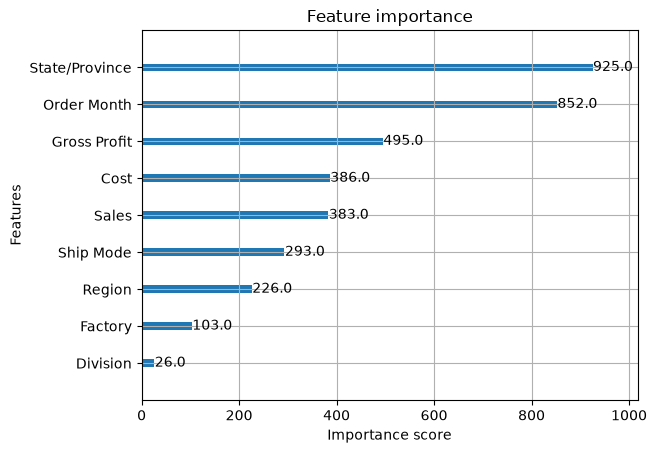

In [88]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xg, max_num_features=10)
plt.show()

In [90]:
import joblib

joblib.dump(xg,"model/CandyDistributerModel.joblib")

['model/CandyDistributerModel.joblib']

## GENAI INTEGRATION

In [ ]:
prompt = f"""
You are an AI Logistics Operations Analyst for Nassau Candy Distributor.

A machine learning model has already predicted the shipment delay risk. The machine learning prediction is the source of truth and must not be changed or questioned.

Your responsibility is to interpret the prediction and provide professional business insights.

### Shipment Information

* Factory: {factory}
* Division: {division}
* State: {state}
* Region: {region}
* Ship Mode: {ship_mode}
* Sales: {sales}
* Cost: {cost}
* Gross Profit: {gross_profit}
* Order Month: {order_month}

### Machine Learning Prediction

* Prediction: {prediction}
* Delay Probability: {probability}%

Generate a professional logistics assessment with the following sections:

## Executive Summary

Provide a concise overview of the shipment status.

## Shipment Risk Assessment

Explain what the prediction means and the level of operational risk.

## Possible Contributing Factors

Discuss possible reasons for the predicted outcome based only on the shipment information provided. Do not invent facts or assume information that is not available.

## Business Impact

Explain how this prediction could affect logistics operations, customer satisfaction, delivery commitments, inventory planning, and business costs.

## Recommendations

Provide 5 practical and actionable recommendations that could reduce the likelihood or impact of shipment delays.

## Priority Level

Return only one of the following:

* LOW
* MEDIUM
* HIGH
* CRITICAL

Use clear, professional business language suitable for logistics managers.

Do not modify the machine learning prediction or probability. Base all explanations and recommendations only on the provided shipment details and ML prediction.



"""